In [2]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from statsmodels.stats.proportion import proportion_confint
from tqdm.notebook import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
from collections import namedtuple
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy import stats
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.power import tt_ind_solve_power

# Работаем с выбросами

full data variance: 1353272585
data without 99 quan variance: 783861938


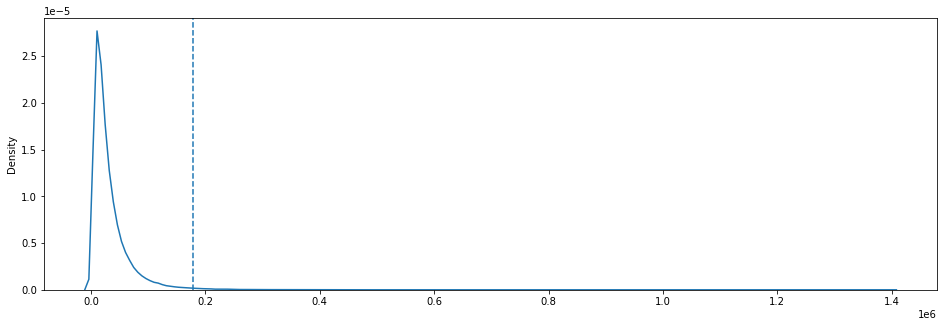

In [3]:
lognorm_data = np.random.lognormal(mean = 10, sigma=0.9, size=100000)
q_99 = np.quantile(lognorm_data, 0.99)
plt.figure(figsize = (16,5))
sns.kdeplot(lognorm_data)
plt.axvline(x =q_99, linestyle = '--')
print('full data variance:', round(lognorm_data.var()))
print('data without 99 quan variance:', round(lognorm_data[lognorm_data < q_99].var()))

In [4]:
def remove_outliers(df, value_name, q):
    new_data = df[df[value_name] < np.quantile(df[value_name], q)]
    return(new_data)

### посмотрим как ведет себя мощность в t-test при работе с выбросами

In [5]:
# в этот раз поработаем с экспоненциальным распределением
exp_data = np.random.exponential(scale = 100, size=100000)
exp_data = pd.DataFrame({'value':exp_data})

In [6]:
# оценим мощность двух тестов через симуляцию при аддитивном эффекте
tstat_list, pval_list, means_diff_list = [], [], []
new_tstat_list, new_pval_list, new_means_diff_list = [], [], []

for _ in tqdm(range(1000)):
    random_data_A = exp_data.sample(n = 1500)
    random_data_B = exp_data.sample(n = 1500) + 10  #добавляем аддитивный эффект
    
    means_diff = random_data_A['value'] - random_data_B['value']
    means_diff_list.append(means_diff)

    random_data_A['group'] = 'A'
    random_data_B['group'] = 'B'

    union_data = pd.concat([random_data_B, random_data_A])
    new_union_data = remove_outliers(union_data, 'value', 0.99)

    new_random_data_A = new_union_data[new_union_data['group'] == 'A']
    new_random_data_B = new_union_data[new_union_data['group'] == 'B']
    
    new_means_diff = new_random_data_A['value'] - new_random_data_B['value']
    new_means_diff_list.append(new_means_diff)

    t_stat, p_value = stats.ttest_ind(random_data_A['value'], random_data_B['value'])
    new_t_stat, new_p_value = stats.ttest_ind(new_random_data_A['value'], new_random_data_B['value'])
    tstat_list.append(t_stat), pval_list.append(p_value)
    new_tstat_list.append(new_t_stat), new_pval_list.append(new_p_value)

print('full data variance:', round(union_data['value'].var()))
print('data without 99 quan variance:', round(new_union_data['value'].var()))    
print('Power for basic t-test = ', (np.array(pval_list) < 0.05).sum() / 1000)
print('Power for new t-test = ', (np.array(new_pval_list) < 0.05).sum() / 1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

full data variance: 10025
data without 99 quan variance: 7835
Power for basic t-test =  0.775
Power for new t-test =  0.834


<AxesSubplot:xlabel='value', ylabel='Density'>

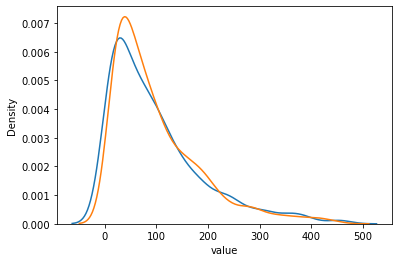

In [7]:
sns.kdeplot(new_random_data_A['value'])
sns.kdeplot(new_random_data_B['value'])

Мощность теста без выбросов действительно выросла. Хотя мы и отрезали 1% наблюдений из выборок. При этом выросла она не кратно.

In [749]:
# оценим мощность двух тестов через симуляцию при мультипликативном эффекте
tstat_list, pval_list, means_diff_list = [], [], []
new_tstat_list, new_pval_list, new_means_diff_list = [], [], []

for _ in tqdm(range(1000)):
    random_data_A = exp_data.sample(n = 1500)
    random_data_B = exp_data.sample(n = 1500) * 1.1  #добавляем мультипликативный эффект  
    means_diff = random_data_A['value'] - random_data_B['value']
    means_diff_list.append(means_diff)

    random_data_A['group'] = 'A'
    random_data_B['group'] = 'B'

    union_data = pd.concat([random_data_B, random_data_A])
    new_union_data = remove_outliers(union_data, 'value', 0.99)

    new_random_data_A = new_union_data[new_union_data['group'] == 'A']
    new_random_data_B = new_union_data[new_union_data['group'] == 'B']
    
    new_means_diff = new_random_data_A['value'] - new_random_data_B['value']
    new_means_diff_list.append(new_means_diff)

    t_stat, p_value = stats.ttest_ind(random_data_A['value'], random_data_B['value'])
    new_t_stat, new_p_value = stats.ttest_ind(new_random_data_A['value'], new_random_data_B['value'])
    tstat_list.append(t_stat), pval_list.append(p_value)
    new_tstat_list.append(new_t_stat), new_pval_list.append(new_p_value)

print('Power for basic t-test = ', (np.array(pval_list) < 0.05).sum() / 1000)
print('Power for new t-test = ', (np.array(new_pval_list) < 0.05).sum() / 1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

Power for basic t-test =  0.722
Power for new t-test =  0.619


При мультипликативном эффекте мощность наоборот упала. Это пример того как отрезание эффекта с помощью выбросов может наоборот испортит тест. Различия между группами стали менее явными. Вероятность ошибки 2 рода выросла.

<AxesSubplot:xlabel='value', ylabel='Density'>

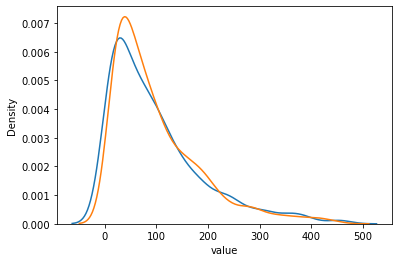

In [34]:
sns.kdeplot(new_random_data_A['value'])
sns.kdeplot(new_random_data_B['value'])

# Работа со стратификацией

### Нам понадобятся полезные функции

In [36]:
# функция для генерации данных в которых есть 2 страты с разными нормальными распределениями

def get_strat_data(population_size, mean_1, mean_2, std_1, std_2, strata_1_frac):
    ''' функция, создающая данные с разными распределениями по стратам нужного размера'''
    values_1 = np.random.normal(mean_1, std_1, round(population_size*(strata_1_frac)))
    values_2 = np.random.normal(mean_2, std_2, round(population_size*(1-strata_1_frac)))
    data_1_df = pd.DataFrame({'value': values_1, 'strata': 'A'})
    data_2_df = pd.DataFrame({'value': values_2, 'strata': 'B'})
    
    union_data = pd.concat([data_1_df, data_2_df], ignore_index = True)
    return(union_data)

In [37]:
hist_data = get_strat_data(1000, 1, 100, 1, 1, 0.2)
hist_data.tail()

,value,strata
995,99.931038,B
996,98.835061,B
997,98.820410,B
998,98.579349,B
999,100.440426,B


In [38]:
def get_strat_sample(data, strata_name, frac, replace = False):
    ''' функция возвращающая стратифицированную выборку нужной фракции. стратификция по strat_name'''
    strat_sample = (data.groupby([strata_name], group_keys = False)
                    .apply(lambda x: x.sample(frac=frac, replace = replace)))
    return(strat_sample)

In [39]:
def get_random_sample(data, frac, replace = False):
    '''функция возвращающая простую случайную выборку нужной фракции'''
    random_sample = data.sample(frac=frac, replace = replace)
    return(random_sample)

In [40]:
def calculate_mean(values):
    '''Вычисляет обычное среднее'''
    return(np.mean(values))

In [41]:
def calculate_strat_mean(data, strata_name, gen_pop_weights, target_value):
    ''' Вычисляет стратифицированное среднее. использует веса из генеральной популяции (передаются как словарь)'''
    strats_means = data.groupby(strata_name)[target_value].mean()

    data_means_weights = pd.merge(
        pd.Series(strats_means, name='value_means'),
        pd.Series(gen_pop_weights, name='weight'),
        how='inner',
        left_index=True,
        right_index=True)

    mean_strat = (data_means_weights['weight'] * data_means_weights['value_means']).sum()
    return(mean_strat)

### Проверим как ведут себя средние при разном сэмплировании
Также проверим несмещенность и разброс

In [42]:
# возьмем две выборки. Простую случайную и стратифицированную
random_sample = get_random_sample(hist_data, 0.1, replace = False)
strat_sample = get_strat_sample(hist_data, 'strata', 0.1, replace = False)

#проверим репрезентативность доли страты
random_sample_nobs = len(random_sample)
random_sample_A_counts = np.sum(random_sample['strata']=='A')
strat_sample_nobs = len(strat_sample)
strat_sample_A_counts = np.sum(strat_sample['strata']=='A')
print('Доля страты А в рандомной выборке', random_sample_A_counts/random_sample_nobs)
print('Доля страты А в стратифицированной выборке', strat_sample_A_counts/strat_sample_nobs)

#z-тест на одну пропорцию страты А в рандомной выборке
stat, pval = proportions_ztest(count=random_sample_A_counts, nobs=random_sample_nobs, value=0.2) # считаем точечную оценку доли для z-теста
print('p-value проверки пропорции страты в рандомной выборке: ', round(pval, 4))

#z-тест на одну пропорцию страты А в стратифицированной выборке
stat, pval = proportions_ztest(count=strat_sample_A_counts, nobs=strat_sample_nobs, value=0.2) # считаем точечную оценку доли для z-теста
print('p-value проверки пропорции страты в страт. выборке: ', pval)


Доля страты А в рандомной выборке 0.21
Доля страты А в стратифицированной выборке 0.2
p-value проверки пропорции страты в рандомной выборке:  0.8061
p-value проверки пропорции страты в страт. выборке:  1.0


- Видно, что стратифицированное сэмплирование собирает выборку с нужной долей страты A
- В рандомной выборке доля страт "скачет"
- Посмотрим создаст ли нам это проблемы

### Посмотрим, как ведут себя простые и стратифицированные средние при разных способах сэмплирования
Проверим несмещенность и разброс этих оценок

  0%|          | 0/1000 [00:00<?, ?it/s]

Data size =  100
mean(bacic_means) = 4.19, mean(strat_means) = 4.19 , mean(poststrat means) = 4.19
std(bacic_means) = 0.19, std(strat_means) = 0.10 , std(poststrat means) = 0.10


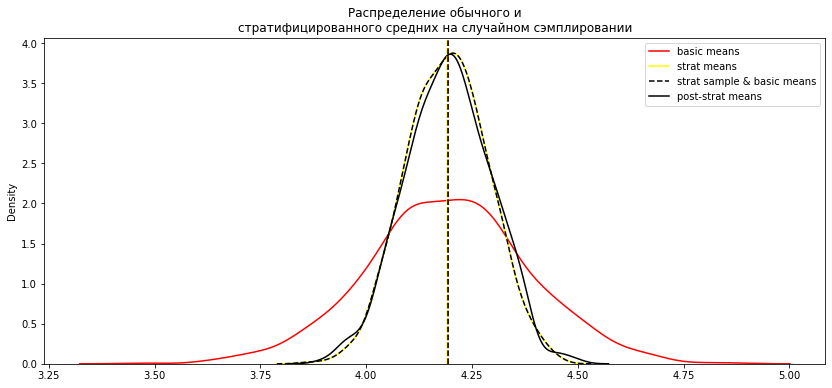

In [43]:
# Будем многократно доставать простую среднюю и стратифицированную среднюю на данных и посмотрим на их распределения
A_strata_prop = 0.2 #создадим исходную долю страты А
#strata A params
mean_1 = 1
std_1 = 1
#starta B params
mean_2 = 5
std_2 = 1

primary_data = get_strat_data(100000, mean_1, mean_2, std_1, std_2, A_strata_prop) #создадим исходные ситрические данн. они будут основом для иллюстрациие

means_list, poststrat_means_list, strat_means_list, strat_means_basic_means_list = [], [], [], []

for _ in tqdm(range(1000)):
    random_data = get_random_sample(primary_data, 0.001)
    strat_data = get_strat_sample(primary_data, 'strata', 0.001)
    
    # простая средняя на рандомных данных
    means_list.append(calculate_mean(random_data['value']))
    # стратифицированная средняя на рандомных данных (постстратификация)
    poststrat_means_list.append(calculate_strat_mean(random_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
    # стратифицированная средняя на стратифицированных данных (стратификация)
    strat_means_list.append(calculate_strat_mean(strat_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
    # простая средняя на стратифицированных данных (стратификация)
    strat_means_basic_means_list.append(calculate_mean(strat_data['value']))
    
print('Data size = ', len(random_data))
print(f'mean(bacic_means) = {np.mean(means_list):0.2f}, mean(strat_means) = {np.mean(strat_means_list):0.2f} , mean(poststrat means) = {np.mean(poststrat_means_list):0.2f}')
print(f'std(bacic_means) = {np.std(means_list):0.2f}, std(strat_means) = {np.std(strat_means_list):0.2f} , std(poststrat means) = {np.std(poststrat_means_list):0.2f}')

plt.figure(figsize = (14,6))
sns.kdeplot(means_list, label = 'basic means', color = 'red')
sns.kdeplot(strat_means_list, label = 'strat means', color = 'yellow')
sns.kdeplot(strat_means_basic_means_list, label = 'strat sample & basic means', color = 'black', linestyle = '--')
sns.kdeplot(poststrat_means_list, label = 'post-strat means', color = 'black')                                        
plt.axvline(x = np.mean(means_list), color = 'red', linestyle = '--')
plt.axvline(x = np.mean(strat_means_list), color = 'yellow', linestyle = '--')
plt.axvline(x = np.mean(poststrat_means_list), color = 'black', linestyle = '--')
plt.title('Распределение обычного и\nстратифицированного средних на случайном сэмплировании')
plt.legend()

- Как мы видим на рандомных данных стратифицированная средняя имеет менее вариационное распределение. и при этом математическое ожидание у двоих логик расчета совпадают
- Также видно, что распределения распределение средних при стратификации очень близок к распределению при постстратификации, мы это видели по сложности 1/n^2.
- Смотря на распределения, мы понимаем почему стратификация увеличивает точность. Теперь выборочные средние имеют меньший разброс, а значит и разница выборочных средних будет иметь меньшее std. что позволит нам сузить ДИ проверки равнства разниысредних с нулем.
- также следует обратить внимание, что если данные стратифицированные, но средняя простая, то распределение получается идентичным стратифицированному варианту. Это вытекает из свойств стратифицированной и простой средней при стратифицированном сэмплирвоании.

### Давайте посмотрим, как будет вести себя вариация оценки средних при различных размерах выборки
возможно где-то есть порог при котором стратификация перестает работать?
Проведем похожую на предыдущею симуляцию. Где еще одним гиперпараметром будет размер выборки.

In [25]:
# Будем многократно доставать простую среднюю и стратифицированную среднюю на данных и посмотрим на их распределения
A_strata_prop = 0.2 #создадим исходную долю страты А
#strata A params
mean_1 = 1
std_1 = 1
#starta B params
mean_2 = 5
std_2 = 1

primary_data = get_strat_data(100000, mean_1, mean_2, std_1, std_2, A_strata_prop) #создадим исходные ситрические данн. они будут основом для иллюстрациие

sample_size_list = np.arange(1, 50, 1)

basic_means_std, poststrat_means_std, strat_means_std = [], [], []

#циклом пройдемся по всем размерам выборки и посмотрим на std распредения разных способов оценки средних в зависимости от размера выборки
for sample_size in tqdm(sample_size_list):

    means_list, poststrat_means_list, strat_means_list = [], [], []
    for _ in range(500):
        random_data = get_random_sample(primary_data, sample_size/len(primary_data)) 
        strat_data = get_strat_sample(primary_data, 'strata', sample_size/len(primary_data))

        means_list.append(calculate_mean(random_data['value']))
        poststrat_means_list.append(calculate_strat_mean(random_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
        strat_means_list.append(calculate_strat_mean(strat_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
    
    basic_means_std.append(np.std(means_list))
    poststrat_means_std.append(np.std(poststrat_means_list))
    strat_means_std.append(np.std(strat_means_list))

  0%|          | 0/49 [00:00<?, ?it/s]

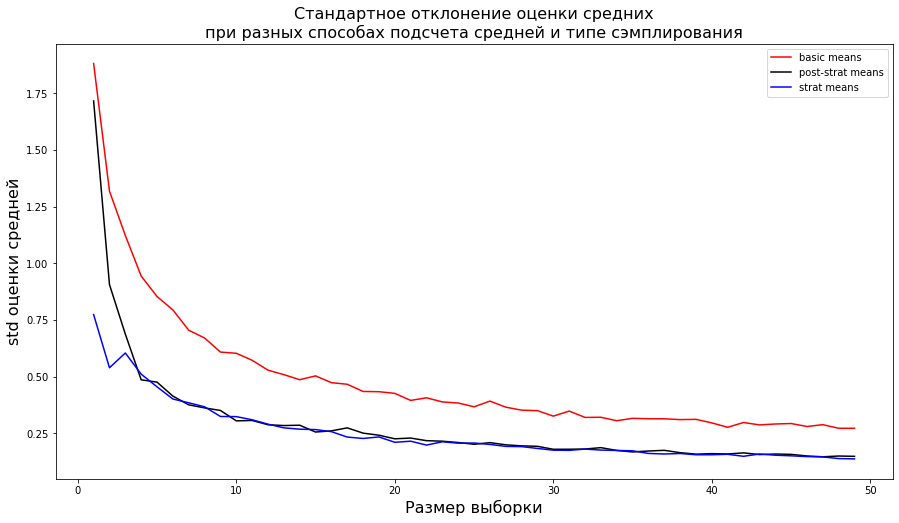

In [312]:
plt.figure(figsize = (15,8))
sns.lineplot(x = sample_size_list, y = basic_means_std, label = 'basic means', color = 'red')
sns.lineplot(x = sample_size_list, y = poststrat_means_std, label = 'post-strat means', color = 'black')
sns.lineplot(x = sample_size_list, y = strat_means_std,  label = 'strat means', color = 'blue')
plt.title('Стандартное отклонение оценки средних\nпри разных способах подсчета средней и типе сэмплирования', fontsize=16)
plt.xlabel("Размер выборки", fontsize=16)
plt.ylabel("std оценки средней", fontsize=16)
plt.legend()

- мы видим, что помере роста выборки разброс оценки средних ожидаемо падает для всех трех способов.
- При этом разница между базовым способом и стратифицированным сохраняется.
- Можно сказать, что, если между стратами есть различия в средних, мы всегда будем выигрывать в двариации средних для стратифицированных методов.
- также видим, что дисперсии средних у пострстратификации и стратификации бычтро сходятся (O(1\n^2)). Эти формулы мы показывали в видео уроке.

### Давайте проверим, действительно ли разница в средних между стратами всегда дает нам снижение вариации оценок средних.
Для этого проведем еще одну симуляцию где гиперпараметром будет сдвиг средней в одной из страт, а оценить мы хотим вариацию средних в группе.

Давайте проведем симуляцию на не очень большой выборке. Например на 100 наблюдениях.

In [26]:
# Будем многократно доставать простую среднюю и стратифицированную среднюю на данных и посмотрим на их распределения
A_strata_prop = 0.2 #создадим исходную долю страты А
#strata A params
mean_1 = 1
std_1 = 1
#starta B params
std_2 = 1

uplift_list = np.arange(0, 5, 0.5)

basic_means_std, poststrat_means_std, strat_means_std = [], [], []

#циклом пройдемся по всем размерам выборки и посмотрим на std распредения разных способов оценки средних
for uplift in tqdm(uplift_list):
    primary_data = get_strat_data(100000, mean_1, mean_1*(1+uplift), std_1, std_2, A_strata_prop)
    means_list, poststrat_means_list, strat_means_list = [], [], []
    for _ in range(500):
        random_data = get_random_sample(primary_data, 0.001) 
        strat_data = get_strat_sample(primary_data, 'strata', 0.001)

        means_list.append(calculate_mean(random_data['value']))
        poststrat_means_list.append(calculate_strat_mean(random_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
        strat_means_list.append(calculate_strat_mean(strat_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
    
    basic_means_std.append(np.std(means_list))
    poststrat_means_std.append(np.std(poststrat_means_list))
    strat_means_std.append(np.std(strat_means_list))

  0%|          | 0/10 [00:00<?, ?it/s]

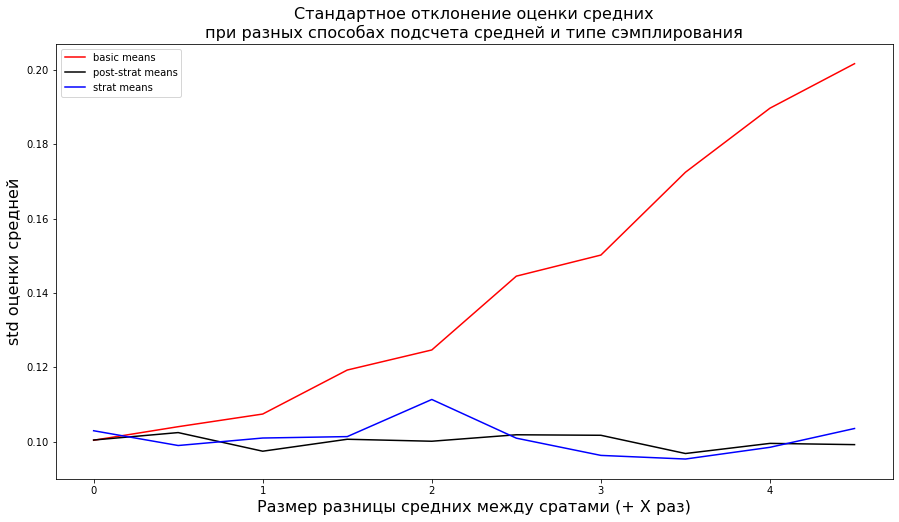

In [44]:
plt.figure(figsize = (15,8))
sns.lineplot(x = uplift_list, y = basic_means_std, label = 'basic means', color = 'red')
sns.lineplot(x = uplift_list, y = poststrat_means_std, label = 'post-strat means', color = 'black')
sns.lineplot(x = uplift_list, y = strat_means_std,  label = 'strat means', color = 'blue')
plt.title('Стандартное отклонение оценки средних\nпри разных способах подсчета средней и типе сэмплирования', fontsize=16)
plt.xlabel("Размер разницы средних между сратами (+ X раз)", fontsize=16)
plt.ylabel("std оценки средней", fontsize=16)
plt.legend()

Как мы видим по графику выше. С ростом разницы средней между стратами растет и вариация простой средней с рандомным сэмплированием. Как помним из лекции это происходит потому что растет межгрупповая дисперсия между стратами, хотя внутри страт std остается таким же.

Этот график наглядно иллюстрирует, что стратификация сниает дисперсию тем лучше, чем выше разница средних между стратами.

# Посмотрим как ведет себя дисперсии величины при разных методах рассчета

In [28]:
random_data = get_random_sample(primary_data, 0.001) 
strat_data = get_strat_sample(primary_data, 'strata', 0.001)

In [29]:
def calculate_strat_var(data, strata_name, gen_pop_weights, target_value):
    '''Вычисляет стратифицированную дисперсию.'''
    
    strat_vars = data.groupby(strata_name)[target_value].var()
    
    data_vars_weights = pd.merge(
        pd.Series(strat_vars, name='value_vars'),
        pd.Series(gen_pop_weights, name='weight'),
        how='inner',
        left_index=True,
        right_index=True)   
 
    var_strat = (data_vars_weights['weight'] * data_vars_weights['value_vars']).sum()
    return (var_strat)

### Давайте посмотрим, как выглядит распределения выборочных дисперсий при разных способах сэмплирвоания и расчета дисперсии

In [46]:
# Будем многократно доставать простую диспресию и стратифицированную дисперсию на данных и посмотрим на их распределения
A_strata_prop = 0.2 # исходная доля страты A

vars_list, poststrat_vars_list, strat_vars_list, strat_sample_basic_var_list = [], [], [], []

for _ in tqdm(range(100)):
    random_data = get_random_sample(primary_data, 0.01) # достаем случайную выборку
    strat_data = get_strat_sample(primary_data, 'strata', 0.01) # достаем стратифицированную выборку
    
    # простая дисперсия на рандомных данных
    vars_list.append((random_data['value'].var()))
    # стратифицированная дисперсия на рандомных данных (постстратификация)
    poststrat_vars_list.append(calculate_strat_var(random_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
    # стратифицированная дисперсия на стратифицированных данных (стратификация)
    strat_vars_list.append(calculate_strat_var(strat_data, 'strata', {'A':A_strata_prop, 'B':(1-A_strata_prop)}, 'value'))
    # простая дисперсия на стратифицированных данных (стратификация)
    strat_sample_basic_var_list.append(strat_data['value'].var())
    
print('Data size = ', len(random_data))
print(f'mean(bacic_vars) = {np.mean(vars_list):0.2f}, mean(strat_vars) = {np.mean(strat_vars_list):0.2f} , mean(poststrat_vars) = {np.mean(poststrat_vars_list):0.2f}')
print(f'std(bacic_vars) = {np.std(vars_list):0.2f}, std(strat_vars) = {np.std(strat_vars_list):0.2f} , std(poststrat_vars) = {np.std(poststrat_vars_list):0.2f}')

  0%|          | 0/100 [00:00<?, ?it/s]

Data size =  1000
mean(bacic_vars) = 3.57, mean(strat_vars) = 1.00 , mean(poststrat_vars) = 1.00
std(bacic_vars) = 0.16, std(strat_vars) = 0.04 , std(poststrat_vars) = 0.04


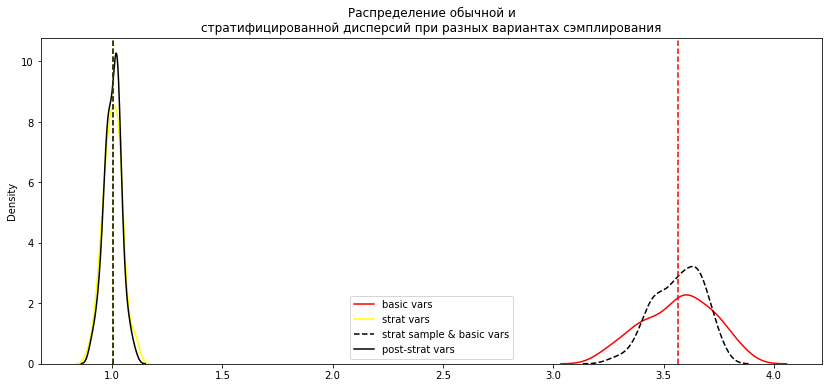

In [47]:
plt.figure(figsize = (14,6))
sns.kdeplot(vars_list, label = 'basic vars', color = 'red')
sns.kdeplot(strat_vars_list, label = 'strat vars', color = 'yellow')
sns.kdeplot(strat_sample_basic_var_list, label = 'strat sample & basic vars', color = 'black', linestyle = '--')
sns.kdeplot(poststrat_vars_list, label = 'post-strat vars', color = 'black')                                        
plt.axvline(x = np.mean(vars_list), color = 'red', linestyle = '--')
plt.axvline(x = np.mean(strat_vars_list), color = 'yellow', linestyle = '--')
plt.axvline(x = np.mean(poststrat_vars_list), color = 'black', linestyle = '--')
plt.title('Распределение обычной и\nстратифицированной дисперсий при разных вариантах сэмплирования')
plt.legend()

- Мы видим, что вне зависимости от типа сэмплирования обычная дисперсия выше стратифицированной на размер межгрупповой дисперсии
- Именно стратифицированную дисперсию мы будем использовать для рассчета размера выборки и для скорректированного t-test

# Научимся проводить стратифицированный ttest
Для этого нам нужны будут функции

In [59]:
# Перепишем фунции для проведения t-test

def get_basic_ttest(group_A, group_B):
    '''Проверяет гипотезу о равенстве средних для обычного среднего.
    return - t_stat, p_value.'''
    
    t_stat, p_value = stats.ttest_ind(group_A, group_B)
    inference = {'t_stat': t_stat, 'p_value':p_value}
    return(inference)


def get_strat_ttest(df_A, df_B, strata_name, target_value, gen_pop_weights):
    """Проверяет гипотезу о равенстве средних для стратифицированного среднего и стратифицировнной дисперсии.
    
    return - pvalue.
    """
    mean_strat_A =  calculate_strat_mean(df_A, strata_name, gen_pop_weights, target_value)
    mean_strat_B =  calculate_strat_mean(df_B, strata_name, gen_pop_weights, target_value)
    
    var_strat_A = calculate_strat_var(df_A, strata_name, gen_pop_weights, target_value)
    var_strat_B = calculate_strat_var(df_B, strata_name, gen_pop_weights, target_value)

    delta_mean_strat = mean_strat_A - mean_strat_B
    std_mean_strat = np.sqrt(var_strat_A / len(df_A) + var_strat_B / len(df_B))
    t_stat_strat = delta_mean_strat / std_mean_strat
    p_value = 2 * (1 - stats.norm.cdf(np.abs(t_stat_strat)))
    
    inference = {'t_stat': t_stat_strat, 'p_value':p_value}
    return (inference)

In [51]:
get_strat_data(100000, mean_1, mean_2, std_1, std_2, A_strata_prop)

,value,strata
0,1.212395,A
1,0.326616,A
2,0.411783,A
3,-0.294048,A
4,2.227700,A
...,...,...
99995,3.229914,B
99996,3.177202,B
99997,4.129362,B
99998,1.179427,B


<AxesSubplot:xlabel='value', ylabel='Density'>

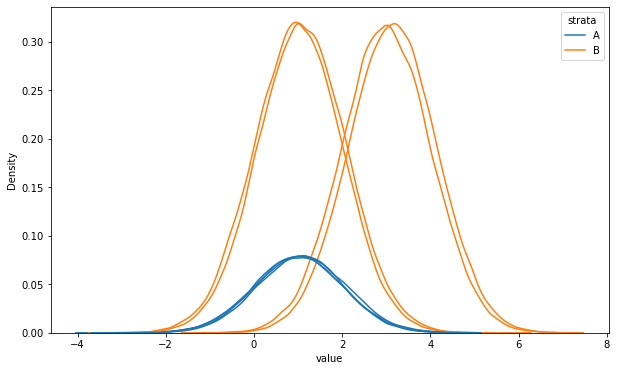

In [57]:
# создадим стратифицированные данные

A_strata_prop = 0.2 #создадим исходную долю страты А
# создали различающиеся по стратам данные
mean_1 = 1
mean_2 = 3
std_1 = 1
std_2 = 1

# стратифицированные данные
primary_data_1 = get_strat_data(100000, mean_1, mean_2, std_1, std_2, A_strata_prop) #исходные страт данные. группа А
primary_data_2 = get_strat_data(100000, mean_1*(1+0.05), mean_2*(1+0.05), std_1, std_2, A_strata_prop) #исходные страт данные. группа В

# обычные нормальные данные
non_strat_primary_data_1 = get_strat_data(100000, mean_1, mean_1, std_1, std_2, A_strata_prop) #исходные не страт данные. группа А
non_strat_primary_data_2 = get_strat_data(100000, mean_1*(1+0.1), mean_1*(1+0.1), std_1, std_2, A_strata_prop) #исходные не страт данные с эффектом . группа В
# обратите внимание, что в этот раз эффект мы заложили выше, чтобы выравнять Cohen В effect size со страт группой. Чтобы можно было сопоставлять мощность

plt.figure(figsize= (10,6))
sns.kdeplot(data = primary_data_1, x = 'value', hue = 'strata')
sns.kdeplot(data = primary_data_2, x = 'value', hue = 'strata')
sns.kdeplot(data = non_strat_primary_data_1, x = 'value', hue = 'strata')
sns.kdeplot(data = non_strat_primary_data_2, x = 'value', hue = 'strata')

In [60]:
# проведем 1 АБ-тест и сравним результыты в простом t-test и стратифицированном
random_data_A = get_random_sample(primary_data_1, 0.01)
random_data_B = get_random_sample(primary_data_2, 0.01)
print('basic_ttest', get_basic_ttest(random_data_A['value'], random_data_B['value']))
print('strat_t-test', get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8}))

basic_ttest {'t_stat': -3.1038920715651455, 'p_value': 0.00193669384898874}
strat_t-test {'t_stat': -3.6586364883882077, 'p_value': 0.0002535606912670296}


# Оценим мощность и статзначимость тестов со стратификацией

In [63]:
# оценим мощность двух тестов через симуляцию
basic_tstat_list_rs, strat_tstat_list_rs,  strat_tstat_list_ss = [], [], []
basic_pval_list_rs, strat_pval_list_rs, strat_pval_list_ss = [], [], []
sim_num = 500
for _ in tqdm(range(sim_num)):
    random_data_A = get_random_sample(primary_data_1, 0.01) # постстратификация
    random_data_B = get_random_sample(primary_data_2, 0.01)
    
    strat_data_A = get_strat_sample(primary_data_1, 'strata', 0.01)
    strat_data_B = get_strat_sample(primary_data_2, 'strata', 0.01)
    
    basic_tstat_rs = get_basic_ttest(random_data_A['value'], random_data_B['value'])['t_stat']
    basic_pval_rs = get_basic_ttest(random_data_A['value'], random_data_B['value'])['p_value']
    
    strat_tstat_rs = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['t_stat']
    strat_pval_rs = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['p_value']
    
    strat_tstat_ss = get_strat_ttest(strat_data_A, strat_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['t_stat']
    strat_pval_ss = get_strat_ttest(strat_data_A, strat_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['p_value']
    
    basic_tstat_list_rs.append(basic_tstat_rs)
    basic_pval_list_rs.append(basic_pval_rs)
    strat_tstat_list_rs.append(strat_tstat_rs)
    strat_pval_list_rs.append(strat_pval_rs)
    strat_tstat_list_ss.append(strat_tstat_ss)
    strat_pval_list_ss.append(strat_pval_ss)

  0%|          | 0/500 [00:00<?, ?it/s]

Power for basic t-test= 0.558
95% CI for power for basic t-test: (0.5144697338004759, 0.6015302661995242)
--------------------
Power for post-strat t-test= 0.816
95% CI for power for strat t-test: (0.7820361370520283, 0.8499638629479715)
--------------------
Power for strat t-test= 0.788
95% CI for power for strat t-test: (0.7521743459306078, 0.8238256540693922)


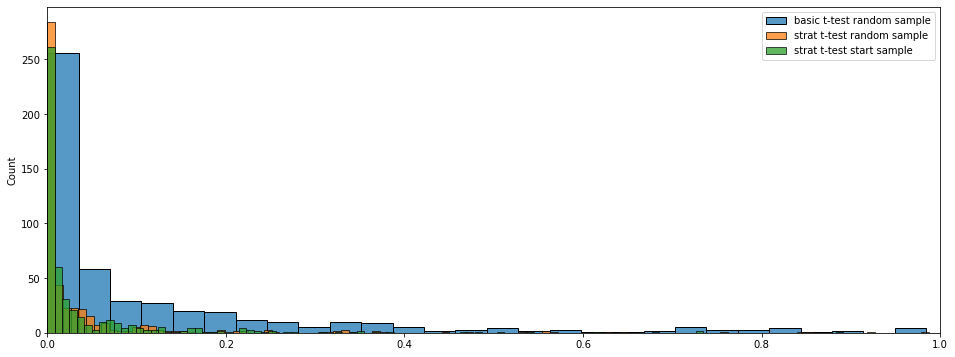

In [64]:
plt.figure(figsize= (16,6))
sns.histplot(basic_pval_list_rs, label = 'basic t-test random sample')
sns.histplot(strat_pval_list_rs, label = 'strat t-test random sample')
sns.histplot(strat_pval_list_ss, label = 'strat t-test start sample')
plt.xlim((0, 1))
plt.legend()
print('Power for basic t-test=', (np.sum(np.array(basic_pval_list_rs) < 0.05))/sim_num)
print('95% CI for power for basic t-test:', proportion_confint(np.sum(np.array(basic_pval_list_rs) < 0.05), sim_num))
print('--------------------')
print('Power for post-strat t-test=', (np.sum(np.array(strat_pval_list_rs) < 0.05))/sim_num)
print('95% CI for power for strat t-test:', proportion_confint(np.sum(np.array(strat_pval_list_rs) < 0.05), sim_num))
print('--------------------')
print('Power for strat t-test=', (np.sum(np.array(strat_pval_list_ss) < 0.05))/sim_num)
print('95% CI for power for strat t-test:', proportion_confint(np.sum(np.array(strat_pval_list_ss) < 0.05), sim_num))

- Как видно из графика выше у стратифицированного t-test есть прирост по мощности
- t-test на стратификации и постстратификации показывает очень близкие значения

### Давайте посмотрим как ведут себя тесты при отстутствии разницы между стратами

In [65]:
# оценим мощность двух тестов через симуляцию
basic_tstat_list, strat_tstat_list = [], []
basic_pval_list, strat_pval_list = [], []
sim_num = 500
for _ in tqdm(range(sim_num)):
    random_data_A = get_random_sample(non_strat_primary_data_1, 0.01) # постстратификация
    random_data_B = get_random_sample(non_strat_primary_data_2, 0.01)
    basic_tstat = get_basic_ttest(random_data_A['value'], random_data_B['value'])['t_stat']
    basic_pval = get_basic_ttest(random_data_A['value'], random_data_B['value'])['p_value']
    strat_tstat = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['t_stat']
    strat_pval = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['p_value']

    basic_tstat_list.append(basic_tstat)
    basic_pval_list.append(basic_pval)
    strat_tstat_list.append(strat_tstat)
    strat_pval_list.append(strat_pval)

  0%|          | 0/500 [00:00<?, ?it/s]

Power for basic t-test= 0.598
95% CI for power for basic t-test: (0.5550239291079423, 0.6409760708920577)
--------------------
Power for strat t-test= 0.594
95% CI for power for strat t-test: (0.5509553354053286, 0.6370446645946714)


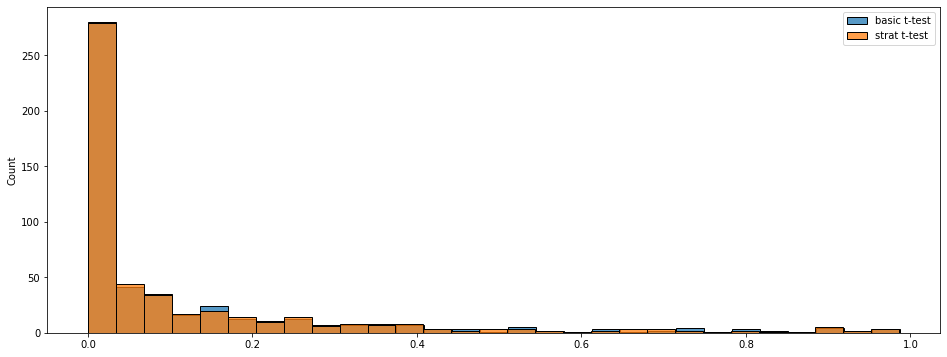

In [66]:
plt.figure(figsize= (16,6))
sns.histplot(basic_pval_list, label = 'basic t-test')
sns.histplot(strat_pval_list, label = 'strat t-test')
plt.legend()
print('Power for basic t-test=', (np.sum(np.array(basic_pval_list) < 0.05))/sim_num)
print('95% CI for power for basic t-test:', proportion_confint(np.sum(np.array(basic_pval_list) < 0.05), sim_num))
print('--------------------')
print('Power for strat t-test=', (np.sum(np.array(strat_pval_list) < 0.05))/sim_num)
print('95% CI for power for strat t-test:', proportion_confint(np.sum(np.array(strat_pval_list) < 0.05), sim_num))

Как мы видим, без разницы средних между стратами стратифицированный t-test показыват такие же результаты, что и обычный t-test

### Оценим контроль уровня ошибки первого рода в стратифицированном t-test

In [83]:
# оценим статзначимость двух тестов через симуляцию
basic_tstat_list, strat_tstat_list = [], []
basic_pval_list, strat_pval_list = [], []
sim_num = 2000
for _ in tqdm(range(sim_num)):
    random_data_A = get_random_sample(primary_data_1, 0.01) # постстратификация 
    random_data_B = get_random_sample(primary_data_1, 0.01) # постстратификация 
    basic_tstat = get_basic_ttest(random_data_A['value'], random_data_B['value'])['t_stat']
    basic_pval = get_basic_ttest(random_data_A['value'], random_data_B['value'])['p_value']
    strat_tstat = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['t_stat']
    strat_pval = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['p_value']

    basic_tstat_list.append(basic_tstat)
    basic_pval_list.append(basic_pval)
    strat_tstat_list.append(strat_tstat)
    strat_pval_list.append(strat_pval)

  0%|          | 0/2000 [00:00<?, ?it/s]

sample size = 1000
Alpha for basic t-test= 0.0435
95% CI for alpha for basic t-test: (0.03456035632011163, 0.05243964367988836)
-------------------
Alpha for strat t-test= 0.0455
95% CI for alpha for strat t-test: (0.036366720298325446, 0.05463327970167455)


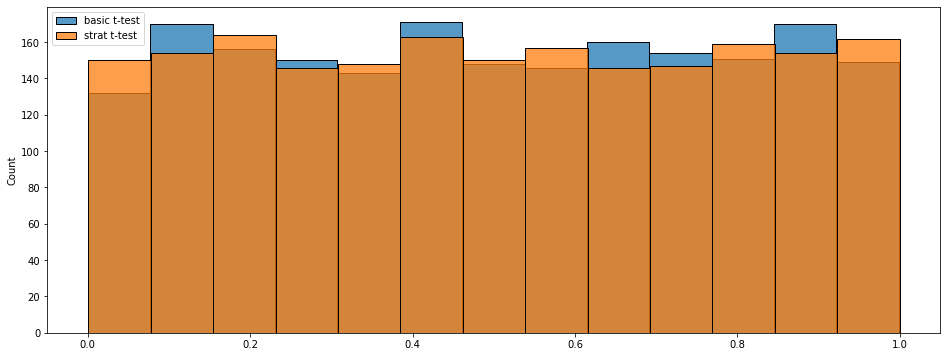

In [84]:
plt.figure(figsize= (16,6))
sns.histplot(basic_pval_list, label = 'basic t-test')
sns.histplot(strat_pval_list, label = 'strat t-test')
plt.legend()
print('sample size =', len(random_data_A))
print('Alpha for basic t-test=', (np.sum(np.array(basic_pval_list) < 0.05))/sim_num)
print('95% CI for alpha for basic t-test:', proportion_confint(np.sum(np.array(basic_pval_list) < 0.05), sim_num))
print('-------------------')
print('Alpha for strat t-test=', (np.sum(np.array(strat_pval_list) < 0.05))/sim_num)
print('95% CI for alpha for strat t-test:', proportion_confint(np.sum(np.array(strat_pval_list) < 0.05), sim_num))

Как видно из графика вышу оба теста показывают уровни стат значимости около 0.05

# Оценка размера выборки при стратификации
Научимся рассчитывать размер выборки для тестов на стратификацию. Ведь мы хотим ускорять тесты.
Это можно делать как аналитически через формулу для определения

In [79]:
#зададим исходные распределения
rel_MDE = 0.05
A_strata_prop = 0.2 #создадим исходную долю страты А
# создали различающиеся по стратам данные
mean_1 = 1
mean_2 = 3
std_1 = 1
std_2 = 1

primary_data_1 = get_strat_data(100000, mean_1, mean_2, std_1, std_2, A_strata_prop) #исходные страт данные. группа А
primary_data_2 = get_strat_data(100000, mean_1, mean_2, std_1, std_2, A_strata_prop)  #исходные страт данные. группа В
primary_data_2['value'] = primary_data_2['value'] * (1 + rel_MDE)

primary_data_1_mean = primary_data_1['value'].mean()
primary_data_2_mean = primary_data_2['value'].mean()

print('primary_data_1 mean =', primary_data_1_mean)
print('primary_data_2 mean =', primary_data_2_mean)

abs_MDE = primary_data_1_mean * rel_MDE#abs(primary_data_2_mean - primary_data_1_mean)
print ('ABS MDE = ', abs_MDE)
print ('rel MDE = ', abs_MDE/primary_data_1_mean)

basic_std = primary_data_1['value'].std()
strat_std = calculate_strat_var(primary_data_1, 'strata', {'A':0.2, 'B':0.8}, 'value') ** 0.5

basic_cohen_D_effect_size = round(abs_MDE / basic_std, 2)
strat_cohen_D_effect_size = round(abs_MDE / strat_std, 2)

print('basic Cohen D effect size = ', basic_cohen_D_effect_size)
print('strat Cohen D effect size = ', strat_cohen_D_effect_size)

strat_sample_size = int(tt_ind_solve_power(effect_size = strat_cohen_D_effect_size, alpha=0.05, power=0.8, nobs1=None, ratio=1))
basic_sample_size = int(tt_ind_solve_power(effect_size = basic_cohen_D_effect_size, alpha=0.05, power=0.8, nobs1=None, ratio=1))

print('Basic sample size = {} / Stratified sample size = {}'.format(basic_sample_size, strat_sample_size))

primary_data_1 mean = 2.5983402829192452
primary_data_2 mean = 2.7300526988782314
ABS MDE =  0.12991701414596227
rel MDE =  0.05
basic Cohen D effect size =  0.1
strat Cohen D effect size =  0.13
Basic sample size = 1570 / Stratified sample size = 929


In [80]:
# проверим базовую формулу
# проверим дает ли нам данные размеры выборки гарантируют  нуную мощность 0.8

# оценим мощность двух тестов через симуляцию
basic_tstat_list, basic_pval_list = [], []

sim_num = 500
for _ in tqdm(range(sim_num)):
    random_data_A = get_random_sample(primary_data_1, basic_sample_size / len(primary_data_1))
    random_data_B = get_random_sample(primary_data_2, basic_sample_size / len(primary_data_2))
    basic_tstat = get_basic_ttest(random_data_A['value'], random_data_B['value'])['t_stat']
    basic_pval = get_basic_ttest(random_data_A['value'], random_data_B['value'])['p_value']
   
    basic_tstat_list.append(basic_tstat)
    basic_pval_list.append(basic_pval)

  0%|          | 0/500 [00:00<?, ?it/s]

Sample size =  1570
Power for basic t-test= 0.78
Power for strat t-test= 0.78
95% CI for power for basic t-test: (0.7436903777593016, 0.8163096222406985)


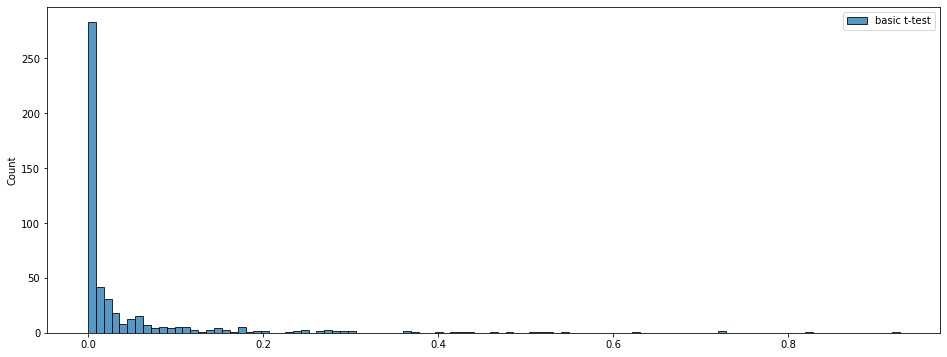

In [81]:
plt.figure(figsize= (16,6))
sns.histplot(basic_pval_list, label = 'basic t-test')
plt.legend()
print('Sample size = ', basic_sample_size)
print('Power for basic t-test=', (np.sum(np.array(basic_pval_list) < 0.05))/sim_num)
print('Power for strat t-test=', (np.sum(np.array(basic_pval_list) < 0.05))/sim_num)
print('95% CI for power for basic t-test:', proportion_confint(np.sum(np.array(basic_pval_list) < 0.05), sim_num))

Как видно из симуляцмм выше базовый t-test показывает ожидаемую мощность на размере выборки посчитанном аналитически

In [73]:
# проверим дает ли нам данные размеры выборки гарантируют  нуную мощность 0.8 при стратифицированном тесте

# оценим мощность двух тестов через симуляцию
strat_tstat_list, strat_pval_list = [], []

sim_num = 500
for _ in tqdm(range(sim_num)):
    random_data_A = get_random_sample(primary_data_1, strat_sample_size / len(primary_data_1))
    random_data_B = get_random_sample(primary_data_2, strat_sample_size / len(primary_data_2))
    strat_tstat = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['t_stat']
    strat_pval = get_strat_ttest(random_data_A, random_data_B, 'strata', 'value', {'A':0.2, 'B':0.8})['p_value']
   
    strat_tstat_list.append(strat_tstat)
    strat_pval_list.append(strat_pval)

  0%|          | 0/500 [00:00<?, ?it/s]

Sample size =  929
Power for basic t-test= 0.794
95% CI for power for basic t-test: (0.7585507582437081, 0.829449241756292)


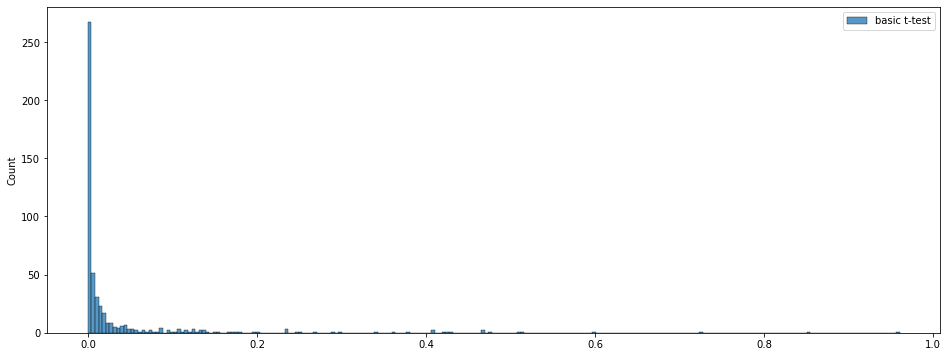

In [74]:
plt.figure(figsize= (16,6))
sns.histplot(basic_pval_list, label = 'basic t-test')
plt.legend()
print('Sample size = ', strat_sample_size)
print('Power for basic t-test=', (np.sum(np.array(strat_pval_list) < 0.05))/sim_num)
print('95% CI for power for basic t-test:', proportion_confint(np.sum(np.array(strat_pval_list) < 0.05), sim_num))

Как видно из симуляции выше, на размере выборки посчитанном аналитически по скорректированной формуле, мы достигаем нужной мощности теста.Значит мы могли бы использовать эту формулу в реальной жизни.